This nbook imports the same Frieburg 16bit int data and exports it as a 32bit int Python lay/dat import.

In [1]:
import numpy as np
import os
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#define files
path='/Volumes/R1Ahub/DATA/DATA_PUBLIC/EiEEG/inv/pat_FR_1096/adm_1096102/rec_109600102/'
stem='109600102_0000'
datFile=os.path.join(path,stem+".data")
hdrFile=os.path.join(path,stem+".head")

# IMPORT HEADER

In [3]:
hdrDf=pd.read_csv(hdrFile,sep='=',header=None,names=['Key','Val'])
hdrDict=pd.read_csv(hdrFile,sep='=',header=None,index_col=0, squeeze=True).to_dict()
print(hdrDf.head())
calibration = float(hdrDict['conversion_factor']) # number for scaling waveform data
startDateTime=datetime.strptime(hdrDict['start_ts'],'%Y-%m-%d %H:%M:%S.%f')
elecNamesClean=hdrDict['elec_names'][1:-1] # remove leading [ and trailing ]
elecNameList=elecNamesClean.split(',')
#TODO check that this is always sample_bytes=2

                 Key                      Val
0           start_ts  2009-06-18 11:54:01.000
1        num_samples                  3686400
2        sample_freq                     1024
3  conversion_factor                 0.179000
4       num_channels                      100


In [86]:
print(hdrDict.keys())
print(hdrDict['num_channels'])
print(hdrDict['sample_freq'])
elecNamesClean=hdrDict['elec_names'][1:-1]
print(elecNamesClean)
elecNameList=elecNamesClean.split(',')
# print(type(elecNameList))
print(elecNameList)
print(len(elecNameList))
# print(hdrDict['elec_names'])

dict_keys(['sample_freq', 'sample_bytes', 'duration_in_sec', 'elec_names', 'num_channels', 'rec_id', 'adm_id', 'start_ts', 'conversion_factor', 'num_samples', 'pat_id'])
100
1024
GA1,GA2,GA3,GA4,GA5,GA6,GA7,GA8,GB1,GB2,GB3,GB4,GB5,GB6,GB7,GB8,GC1,GC2,GC3,GC4,GC5,GC6,GC7,GC8,GD1,GD2,GD3,GD4,GD5,GD6,GD7,GD8,HL1,HL2,HL3,HL4,HL5,HL6,HL7,HL8,HL9,HL10,TBA1,TBA2,TBA3,TBA4,TBB1,TBB2,TBB3,TBB4,TBC1,TBC2,TBC3,TBC4,TBC5,TBC6,HRA1,HRA2,HRA3,HRA4,HRA5,ECG,HRB1,HRB2,HRB3,HRB4,HRB5,HRC1,HRC2,HRC3,HRC4,HRC5,TP1,TP2,TP3,TP4,FP1,FP2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,FZ,CZ,PZ,T1,T2,EOG1,EOG2,EMG
['GA1', 'GA2', 'GA3', 'GA4', 'GA5', 'GA6', 'GA7', 'GA8', 'GB1', 'GB2', 'GB3', 'GB4', 'GB5', 'GB6', 'GB7', 'GB8', 'GC1', 'GC2', 'GC3', 'GC4', 'GC5', 'GC6', 'GC7', 'GC8', 'GD1', 'GD2', 'GD3', 'GD4', 'GD5', 'GD6', 'GD7', 'GD8', 'HL1', 'HL2', 'HL3', 'HL4', 'HL5', 'HL6', 'HL7', 'HL8', 'HL9', 'HL10', 'TBA1', 'TBA2', 'TBA3', 'TBA4', 'TBB1', 'TBB2', 'TBB3', 'TBB4', 'TBC1', 'TBC2', 'TBC3', 'TBC4', 'TBC5', 'TBC6', 

In [78]:
print(startDateTime)
print(startDateTime.strftime('%Y.%m.%d'))
print(startDateTime.strftime('%H:%M:%S'))

2009-06-18 11:54:01
2009.06.18
11:54:01


# Import Waveforms

In [14]:
datFileId = open(datFile,'rb')
    
#preallocate memory
nChan=int(hdrDict['num_channels'])
if (nChan!=len(elecNameList)):
    error("{} num_channels {} does not match the number of labels in elec_names".format(hdrFile,nChan,len(elecNameList)))
nTpt=int(hdrDict['num_samples'])
dat=np.fromfile(datFileId,dtype=np.int16,count=-1)
dat=np.reshape(dat,(nChan,-1),'F') # 'F' is the order (row vs. column); could be 'C' or 'A'
#dat=dat.astype(np.float32)*calibration ??? UNDO?
datFileId.close()
print(dat.shape)
# dat=np.zeros((nChan,nTpt))
# for t in range(nTpt):
#     for c in range(nChan):
        

(100, 3686400)


In [15]:
type(dat[0,0])

numpy.int16

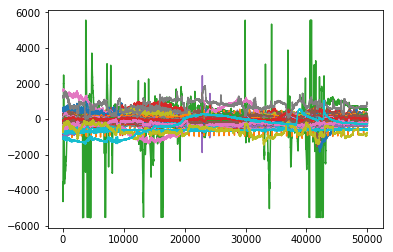

In [5]:
f=plt.figure()
plt.plot(dat[:,:5000*10].T);

# CREATE OUTPUT FILENAMES

In [9]:
outPath='/Users/davidgroppe/Dropbox/TEMP'
outDatFname=os.path.join(outPath,stem+'.dat')
outLayFname=os.path.join(outPath,stem+'.lay')

In [10]:
dat.shape

(100, 3686400)

# CREATE DAT FILE

In [13]:
# CONVERT TO FLOAT
psCalibration=0.2 # Calibration for Persyst files; what should I set this to?
#calibration=1
#calibration=0.0001

# Write dat file USING NUMPY
if os.path.isfile(outDatFname):
    os.remove(outDatFname) 
psDatId = open(outDatFname, mode='wb')
#tempNtpt=10000
tempNtpt=nTpt
outDat=dat[:,:tempNtpt]/psCalibration # you have to do this before converting to int32
#outDat=np.zeros((nChan,tempNtpt)) # REMOVE ME!!!!!
outDatInt=np.array(outDat, dtype='i').T #convert to int32
#outDatInt=outDatInt.reshape(1,nChan*tempNtpt)
outDatInt=outDatInt.reshape(nChan*tempNtpt,1)
outDatInt.tofile(psDatId)
psDatId.close()
print('Done writing {}'.format(outDatFname))

Done writing /Users/davidgroppe/Dropbox/TEMP/109600102_0000.dat


In [19]:
# WRITE DAT FILE WITHOUT CONVERTING TO FLOAT32

# Write dat file USING NUMPY
if os.path.isfile(outDatFname):
    os.remove(outDatFname) 
psDatId = open(outDatFname, mode='wb')
#tempNtpt=10000
tempNtpt=nTpt
outDat=dat[:,:tempNtpt].T
#outDat=dat[:,:tempNtpt]/calibration # you have to do this before converting to int32
#outDat=np.zeros((nChan,tempNtpt)) # REMOVE ME!!!!!
#outDatInt=np.array(outDat, dtype='i').T #convert to int32
#outDatInt=outDatInt.reshape(1,nChan*tempNtpt)
outDatInt=outDat.reshape(nChan*tempNtpt,1)
outDatInt.tofile(psDatId)
psDatId.close()
print('Done writing {}'.format(outDatFname))

Done writing /Users/davidgroppe/Dropbox/TEMP/109600102_0000.dat


In [18]:
print(calibration)

0.179


In [120]:
for a in range(len(elecNameList)):
    if (elecNameList[a]=='HL1'):
        print(a)

32


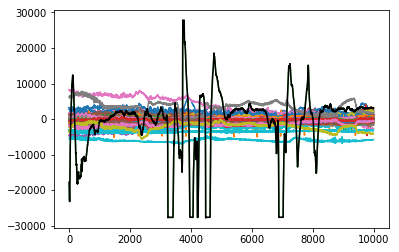

In [121]:
f=plt.figure()
plt.plot(outDat.T);
plt.plot(outDat[32,:],'k-');

In [107]:
dat.shape

(100, 3686400)

In [106]:
# NO CONVERSION NUMPY WRITE
#psCalibration=0.2 # Calibration for Persyst files
#calibration=1
#calibration=0.0001

# Write dat file
os.remove(outDatFname) 
psDatId = open(outDatFname, mode='wb')
#outDat=dat/calibration # you have to do this before converting to int32
#outDatInt=np.array(outDat, dtype='i')
#outDatInt=outDatInt.reshape(1,nChan*nTpt) # ORIG
#outDatInt=outDatInt.reshape(nChan*nTpt,1)
# calibration=0.2; % ?? what should I set this to? was 0.2
# fwrite(fileID,reshape(ieeg/calibration,1,s(1)*s(2)),'int32','ieee-le');
#outDatInt=np.array(np.zeros((1,nChan*nTpt)),dtype='i')
#outDatInt=np.array(np.zeros((nChan*nTpt,1)),dtype='i')
outDatInt=np.array(np.zeros((nTpt,1)),dtype='i')
#outDatInt=outDatInt.reshape(1,nChan*nTpt) # ORIG
#outDatInt=outDatInt.reshape(nChan*nTpt,1)
outDatInt.tofile(psDatId)
psDatId.close()
print('Done writing {}'.format(outDatFname))

Done writing /Users/davidgroppe/Dropbox/TEMP/109600102_0000.dat


In [ ]:
# NO CONVERSION SCIPY WRITE
#psCalibration=0.2 # Calibration for Persyst files
#calibration=1
#calibration=0.0001

# Write dat file
from scipy.io.numpyio import fwrite
os.remove(outDatFname) 
psDatId = open(outDatFname, mode='wb')
#outDat=dat/calibration # you have to do this before converting to int32
#outDatInt=np.array(outDat, dtype='i')
#outDatInt=outDatInt.reshape(1,nChan*nTpt) # ORIG
#outDatInt=outDatInt.reshape(nChan*nTpt,1)
# calibration=0.2; % ?? what should I set this to? was 0.2
# fwrite(fileID,reshape(ieeg/calibration,1,s(1)*s(2)),'int32','ieee-le');
#outDatInt=np.array(np.zeros((1,nChan*nTpt)),dtype='i')
#outDatInt=np.array(np.zeros((nChan*nTpt,1)),dtype='i')
outDatInt=np.array(np.zeros((nTpt,1)),dtype='i')
#outDatInt=outDatInt.reshape(1,nChan*nTpt) # ORIG
#outDatInt=outDatInt.reshape(nChan*nTpt,1)
#outDatInt.tofile(psDatId)
fwrite(psDatId,outDataInt.size,outDataInt)
psDatId.close()
print('Done writing {}'.format(outDatFname))

In [69]:
#sbox code
testDate=hdrDict['start_ts'].split(' ')[0]
print(testDate)
#start_ts=2009-06-18 11:54:01.000
startDateTime=datetime.strptime(hdrDict['start_ts'],'%Y-%m-%d %H:%M:%S.%f')
print(startDateTime)
print(startDateTime.microsecond)

2009-06-18
2009-06-18 11:54:01
0


# CREATE LAY FILE

In [91]:
# Create lay file
lay = open(outLayFname, mode='w')
lay.write('[FileInfo]\n')
lay.write('File={}\n'.format(stem + '.dat'))
lay.write('FileType=Interleaved\n')
lay.write('SamplingRate={}\n'.format(hdrDict['sample_freq']))
lay.write('HeaderLength=0\n')
lay.write('Calibration={}\n'.format(psCalibration))
lay.write('WaveformCount={}\n'.format(nChan))
lay.write('DataType=7\n')
lay.write('MainsFrequency=50\n') # TODO double check
lay.write('\n')

lay.write('[Patient]\n');
lay.write('First={}\n'.format(hdrDict['pat_id']))
lay.write('MI=\n')
lay.write('Last=\n')
lay.write('Sex=\n')
lay.write('Hand=\n')
lay.write('BirthDate=1875/01/31\n') # Nihon-Kohden format, TODO see if we can replace this with something meaningful
lay.write('ID=bogusId_{}\n'.format(hdrDict['pat_id']))
lay.write('MedicalRecordN=\n')
lay.write('TestDate={}\n'.format(startDateTime.strftime('%Y.%m.%d'))) 
lay.write('TestTime={}\n'.format(startDateTime.strftime('%H:%M:%S'))) # Note, if there are fractional seconds, you need to accommodate them in [SampleTimes]
lay.write('Physician=\n')
lay.write('Technician=\n')
lay.write('Medications=\n')
lay.write('History=\n')
lay.write('Comments1=\n')
lay.write('Comments2=\n')
lay.write('\n')

lay.write('[Montage]\n')
lay.write('\n')

lay.write('[SampleTimes]\n')
lay.write('[0={}\n'.format(startDateTime.microsecond)) #TODO make sure this works with record with fractional seconds
lay.write('\n')
    
lay.write('[ChannelMap]\n')
# Write channel names
for c in range(len(elecNameList)):
    lay.write('{}-Ref={}\n'.format(elecNameList[c],c+1))
lay.write('\n')

lay.write('[Comments]\n')
lay.write('\n')


lay.close()
print('Done writing {}'.format(outLayFname))

Done writing /Users/davidgroppe/Dropbox/TEMP/109600102_0000.lay
